**This is a project that Predicts the Gender and Age of a periocular image. The periocular region is basically the area surrounding the eyeball but within the orbit. This is a feature rich area that has had great sucess in deep learning models.**

In [ ]:
#Import PyTorch
import torch
from torch import nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from torch import optim

#Import TorchVision
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor
import torchvision.models as models
from torchvision.models import resnet
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torch.utils.data import Dataset

#torchinfo for printing a model summary
from torchinfo import summary

#import other libraries
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
from PIL import Image
import os
import random 
import shutil
from tqdm.auto import tqdm
import zipfile

In [ ]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"

# PeriGender Data pre-processing

1.   First we make Train and Test folders in the main folder
2.   then we extract the labels for gender from the txt files in the folder
3.   Then we create class folders for male and female by transferring the files with the corresponding labels and put it in the train and test folders.
4.   After that we count the number of images in each folder and proceed as required


In [ ]:
# # replace 'input_folder' with the name of the folder containing your data in '/kaggle/input/'
# input_folder = 'ubipr-custom-dataset'

# # replace 'working_folder' with the name of the folder where you want to store the copied data in '/kaggle/working/'
# working_folder = 'my-data'

# # copy the contents of the input folder to the working folder
# shutil.copytree(f'/kaggle/input/{input_folder}', f'/kaggle/working/{working_folder}')


In [ ]:
# data_folder = '/kaggle/working/my-data/ubipr/UBIPeriocular'

# # Set the percentage of data to use for training
# train_percent = 0.9

# files = os.listdir(data_folder)
# image_files = [f for f in files if f.endswith('.jpg')]
# random.shuffle(image_files)
# split_point = int(len(image_files) * train_percent)


# train_files = image_files[:split_point]
# test_files = image_files[split_point:]
# train_folder = os.path.join(data_folder, 'train')
# test_folder = os.path.join(data_folder, 'test')

# if not os.path.exists(train_folder):
#     os.makedirs(train_folder)
# if not os.path.exists(test_folder):
#     os.makedirs(test_folder)

# # Move the training files to the training folder along with their corresponding text file
# for file in train_files:
#     src_path = os.path.join(data_folder, file)
#     dst_path = os.path.join(train_folder, file)
#     shutil.move(src_path, dst_path)
    
#     # get the corresponding text file and move it along with the image file
#     text_file = file.split('.')[0] + '.txt'
#     src_text_path = os.path.join(data_folder, text_file)
#     dst_text_path = os.path.join(train_folder, text_file)
#     shutil.move(src_text_path, dst_text_path)

# # Move the testing files to the testing folder along with their corresponding text file
# for file in test_files:
#     src_path = os.path.join(data_folder, file)
#     dst_path = os.path.join(test_folder, file)
#     shutil.move(src_path, dst_path)
    
#     # get the corresponding text file and move it along with the image file
#     text_file = file.split('.')[0] + '.txt'
#     src_text_path = os.path.join(data_folder, text_file)
#     dst_text_path = os.path.join(test_folder, text_file)
#     shutil.move(src_text_path, dst_text_path)

In [ ]:
# folder_path = '/kaggle/working/my-data/ubipr/UBIPeriocular/test'  
# line_num = 7  # The 7th line in the textfile contains the gender label
# os.makedirs(os.path.join(folder_path, 'male'), exist_ok=True)
# os.makedirs(os.path.join(folder_path, 'female'), exist_ok=True)
# gender = []
# for filename in os.listdir(folder_path):
#     if filename.endswith('.txt'):
#         # read the file contents and extract the desired line
#         with open(os.path.join(folder_path, filename), 'r') as file:
#             img_filename = filename.replace('.txt', '.jpg')
#             img_filepath = os.path.join(folder_path, img_filename) 
#             lines = file.readlines()
#             list_item = lines[line_num - 1].strip().replace(';', '')
#             gender.append(list_item)
#             # move the file to the appropriate subfolder
#             if list_item.lower() == 'male':
#                 shutil.move(os.path.join(folder_path, filename), os.path.join(folder_path, 'male'))
#                 shutil.move(img_filepath, os.path.join(folder_path, 'male', img_filename))

#             elif list_item.lower() == 'female':
#                 shutil.move(os.path.join(folder_path, filename), os.path.join(folder_path, 'female'))
#                 shutil.move(img_filepath, os.path.join(folder_path, 'female', img_filename))

In [ ]:
# folder_path = '/kaggle/working/my-data/ubipr/UBIPeriocular/train'  
# line_num = 7  
# os.makedirs(os.path.join(folder_path, 'male'), exist_ok=True)
# os.makedirs(os.path.join(folder_path, 'female'), exist_ok=True)
# gender = []
# for filename in os.listdir(folder_path):
#     if filename.endswith('.txt'):
#         # read the file contents and extract the desired line
#         with open(os.path.join(folder_path, filename), 'r') as file:
#             img_filename = filename.replace('.txt', '.jpg')
#             img_filepath = os.path.join(folder_path, img_filename) 
#             lines = file.readlines()
#             list_item = lines[line_num - 1].strip().replace(';', '')
#             gender.append(list_item)
#             # move the file to the appropriate subfolder
#             if list_item.lower() == 'male':
#                 shutil.move(os.path.join(folder_path, filename), os.path.join(folder_path, 'male'))
#                 shutil.move(img_filepath, os.path.join(folder_path, 'male', img_filename))

#             elif list_item.lower() == 'female':
#                 shutil.move(os.path.join(folder_path, filename), os.path.join(folder_path, 'female'))
#                 shutil.move(img_filepath, os.path.join(folder_path, 'female', img_filename))


In [ ]:
# # Count the number of images in a folder to see what were working with
# folder_path = "/kaggle/working/balanced_data/balanced_cleaned_data/train/male"
# count = 0

# for filename in os.listdir(folder_path):
#     if filename.endswith(".jpg"):
#         count += 1

# print("Number of JPG files:", count)

***Number of images in each folder***
* no of male images in train : 6584
* no of female images in train : 2584
* no of male images in test : 709
* no of female images in test : 311

Since we fuond that the number of female images were lesser than the male, this would lead to very bad results and create a large bias in the models training. To counter this we augment the existing female images and create some using the same tranformation and thus enlarge the female part of the dataset

In [ ]:
# !mkdir train_augmented_images

In [ ]:
#Define the transformation for augmenting the female images
transform = transforms.Compose([
    transforms.Resize((224, 112)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomInvert(),
    transforms.RandomSolarize(threshold=192.0),
    transforms.RandomCrop((224, 112)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

#give the paths to the folders that we want to augment
female_dir = '/kaggle/input/cleaned-data/UBIPeriocular/train/female'
augmented_dir = '/kaggle/working/train_augmented_images'
target_num_images = 6584   #Since there are 6584 male images, we want to create as many female images
num_female_images = len(os.listdir(female_dir))

#loop over all images and apply the transformation
while num_female_images < target_num_images:
    female_image_path = os.path.join(female_dir, random.choice(os.listdir(female_dir)))
    female_image = Image.open(female_image_path)
    augmented_image = transform(female_image)
    augmented_image_path = os.path.join(augmented_dir, 'augmented_female_{}.jpg'.format(num_female_images))
    transforms.ToPILImage()(augmented_image).save(augmented_image_path)
    num_female_images += 1

# Training our model using ResNet

**We train our model first using pretrainde ResNet models **

1. First we import ResNet into the notbook
2. Then we just pass the data as it is into ResNet after performing a few data transformations

In [ ]:
# Define ResNet-18 model
resnet_18 = resnet.resnet18()

# Load weights from downloaded file
resnet_18.load_state_dict(torch.load('/kaggle/input/resnet-18/resnet18-5c106cde.pth'))

In [ ]:
# Define ResNet-34 model
resnet_34 = resnet.resnet34()

# Load weights from downloaded file
resnet_34.load_state_dict(torch.load('/kaggle/input/resnet34/resnet34-b627a593.pth'))

In [ ]:
# Define ResNet-50 model
resnet_50 = resnet.resnet50()

# Load weights from downloaded file
resnet_50.load_state_dict(torch.load('/kaggle/input/resnet-50/resnet50-0676ba61.pth'))

In [ ]:
# #Use this when Pytorch 2.0 is supported on Kaggle
# resnet18_comipled = torch.compile(resnet_18)
# resnet34_comipled = torch.compile(resnet_34)
# resnet50_comipled = torch.compile(resnet_50)

In [ ]:
# Define the data transformations
transform = transforms.Compose([
    transforms.Resize((224, 112)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create data loaders for train and test sets
train_dir = '/kaggle/input/balanced-data/balanced_cleaned_data/train'
test_dir = '/kaggle/input/balanced-data/balanced_cleaned_data/test'
train_set = datasets.ImageFolder(train_dir, transform=transform)
test_set = datasets.ImageFolder(test_dir, transform=transform)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True,num_workers=2)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=64,num_workers=2)

# Define the model (When Pytorch 2.0 is supported on kaggle, replace resnet_18 with resnet_compiled)
model = resnet_18

# Define an optimizer function
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9,weight_decay=0.01)

# Create a loss function
loss_fn = nn.CrossEntropyLoss()

# Move the model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Train the model
num_epochs = 10

for epoch in tqdm(range(num_epochs)):
    loss = 0.0
    acc = 0.0
    for i, (images, labels) in enumerate(train_loader):
        
        # Move the data to the correct device by using device agnostic code
        images = images.to(device)
        labels = labels.to(device)
                
        # Do the forward pass
        outputs = model(images)
                       
        # Calculate the loss
        loss = loss_fn(outputs, labels)
        
        # Optmizer zero grad
        optimizer.zero_grad()
        
        # Loss backward
        loss.backward()
        
        # Optimizer step
        optimizer.step()
        
        # Print statistics
        loss += loss.item()
        _, preds = torch.max(outputs, 1)
        acc += torch.sum(preds == labels.data)
    
    epoch_loss = loss / len(train_loader.dataset)
    epoch_acc = acc.double() / len(train_loader.dataset)
    print('Epoch [{}/{}], Train Loss: {:.4f}, Train Acc: {:.2f}%'
          .format(epoch+1, num_epochs, epoch_loss, epoch_acc*100))
    
    # Evaluate the model on the test set after each epoch
    model.eval()
    with torch.no_grad():
        loss = 0.0
        acc = 0.0
        val_loss = 0.0
        for images, labels in test_loader:
            
            # Move the data to the correct device by using device agnostic code
            images = images.to(device)
            labels = labels.to(device)
            
            # Do the forward pass
            outputs = model(images)
            
            # Calculate the loss
            loss = loss_fn(outputs, labels)
            
            # Print statistics
            loss += loss.item()
            _, preds = torch.max(outputs, 1)
            acc += torch.sum(preds == labels.data)
        
        epoch_loss = loss / len(test_loader.dataset)
        epoch_acc = acc.double() / len(test_loader.dataset)
        print('Epoch [{}/{}], Test Loss: {:.4f}, Test Acc: {:.2f}%'
              .format(epoch+1, num_epochs, epoch_loss, epoch_acc*100))
        print('Epoch [{}/{}], Validation Loss: {:.4f}\n'
              .format(epoch+1, num_epochs, val_loss))
    #set the model back to training mode
    model.train()


In [ ]:
#Gives us a idea of what the model looks like and shapes after each pass
model = resnet_18
batch_size = 64
summary(model, input_size=(batch_size, 3, 224, 112))


# **Save and load the ResNet model**

In [ ]:
# #Save the model
# torch.save(model.state_dict(), '/kaggle/working/ResNet18_v1.pth')

In [ ]:
# saved_state_dict = torch.load('/kaggle/working/ResNet18_v1.pth')
# model.load_state_dict(saved_state_dict)

# Comparision between ResNet-18, ResNet-34 and ResNet-50

In this section we will look at the results of training on the different pretrained models

In [ ]:
#These lists represent the various train loss and accuracy that we have found between the different models

test_acc_50 =  [0.9412, 0.9678, 0.9437, 0.9695, 0.8151, 0.8360, 0.9309, 0.8238, 0.9309, 0.8608, 0.8977, 0.8987, 0.8376, 0.9357, 0.9277, 0.8810, 0.9293, 0.9180, 0.9084, 0.9068, 0.8781, 0.9051,0.9003, 0.8537, 0.9148]
test_acc_18 =  [0.8151, 0.8333, 0.8555, 0.8725, 0.8747, 0.8569, 0.8881, 0.8765, 0.8915, 0.9019, 0.9228, 0.9244, 0.9244, 0.9260, 0.8778, 0.9260, 0.8379, 0.9164, 0.9277, 0.8476, 0.9341, 0.9148, 0.8891,0.8993, 0.9189]  
test_acc_34 =  [0.9630, 0.9678, 0.9325, 0.9534, 0.9486, 0.9598, 0.8617, 0.9469, 0.9309, 0.8762, 0.9469, 0.8875, 0.9244, 0.8232, 0.9309, 0.8232, 0.9180, 0.9405, 0.9405, 0.8810, 0.9469, 0.8910, 0.9100,0.8746, 0.9248]
test_acc_PeriGender = [0.8457, 0.7878, 0.8987, 0.8955, 0.8971, 0.9116, 0.9084, 0.8810, 0.9293, 0.7926, 0.8971, 0.9019, 0.8939, 0.8939, 0.9084, 0.9019, 0.8328, 0.8891, 0.9084, 0.9084, 0.9180, 0.9325, 0.9164,0.9132, 0.9320]


In [ ]:
# Example lists
acc_list_34 = test_acc_34
acc_list_50 = test_acc_50
acc_list_18 = test_acc_18
acc_list_PG = test_acc_PeriGender

# Plot accuracy vs epochs
plt.plot(range(1, len(acc_list_34)+1), acc_list_34, label='Accuracy (resnet-34)')
plt.plot(range(1, len(acc_list_50)+1), acc_list_50, label='Accuracy (resnet-50)')
plt.plot(range(1, len(acc_list_18)+1), acc_list_18, label='Accuracy (resnet-18)')
plt.plot(range(1, len(acc_list_PG)+1), acc_list_PG, label='Accuracy (PeriGender)')

plt.title('ResNet')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# PeriGender Architecture

The model described as it is in the Research paper has been implemented here. It consists of Residual blocks and Skip connections to make most use of the CNN features

Link to Paper : https://file.techscience.com/ueditor/files/iasc/TSP_IASC-35-3/TSP_IASC_30036/TSP_IASC_30036.pdf

**Architecture of the model as described in the paper**

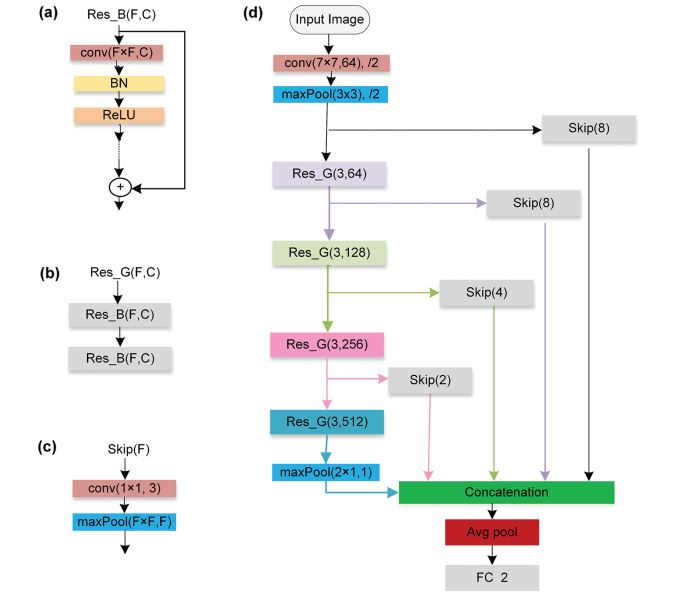
![Screenshot 2023-04-01 at 17-03-31 Unconstrained Gender Recognition from Periocular Region Using Multiscale Deep Features - TSP_IASC_30036.pdf.png](attachment:932b10d1-cbf1-4878-b8a1-309e16511f41.png)

In [ ]:
### The Residual block consists of :
#  Conv_layer_1 ---> Batch_Normalization_1 ---> ReLU_activation_function_1 
#  ---> Conv_layer_2 ---> Batch_Normalization_2 ---> ReLU_activation_function_2 

class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
    
    def forward(self, x):
        
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)
                
        return out


#  The skip connection function consists of simply 2 layers :
#  Conv_layer ---> MaxPool_layer
 
C
        return out
    
class SkipConnection2 (nn.Module):
    def __init__(self, in_channels, out_channels):
        super(SkipConnection2, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels=3, kernel_size=1, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=5, stride=4, padding=0)
        
    def forward(self, x):
        out = self.conv(x)
        out = self.pool(out)
        return out

class SkipConnection3(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(SkipConnection3, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels=3, kernel_size=1, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=4, stride=2, padding=0)

    def forward(self, x):
        out = self.conv(x)
        out = self.pool(out)
        return out


class SkipConnection4(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(SkipConnection4, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels=3, kernel_size=1, stride=1, padding=0)
        self.pool = nn.MaxPool2d(kernel_size=(1,2), stride=(1,1))
        
    def forward(self, x):
        out = self.conv(x)
        out = self.pool(out)
        return out


    
#   The Perigender Layer is a combination of the aforementioned function in the following fashion : 
#    
#      1. Conv_layer_1 --> MaxPool2d_1 
#      2. Skip_function_1
#      3. Residual_batch_1             
#      4. Skip_function_2
#      5. Residual_batch_2
#      6. Skip_function_3
#      7. Residual_function_3
#      8. Skip_function_4
#      9. Residual_function_4  
#     10. MaxPool2d_2
#     11. Concatenation_layer
#     12. AvgPool_layer


class PeriGender(nn.Module):
    def __init__(self, num_classes=2):
        super(PeriGender, self).__init__()

        self.conv = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, stride=2,padding=1)
        self.maxpool1 = nn.MaxPool2d(kernel_size=3, stride=2,padding=1)
        
        self.skip1 = SkipConnection1(64, 64)
        self.resblock1 = nn.Sequential(ResBlock(64, 64, stride=2), ResBlock(64, 128))
        
        self.skip2 = SkipConnection2(128, 128)
        self.resblock2 = nn.Sequential(ResBlock(128, 128, stride=2), ResBlock(128, 256))
        
        self.skip3 = SkipConnection3(256, 256)
        self.resblock3 = nn.Sequential(ResBlock(256, 256, stride=2), ResBlock(256, 512))
        
        self.skip4 = SkipConnection4(512, 4)
        self.resblock4 = nn.Sequential(ResBlock(512, 512, stride=2), ResBlock(512, 512))
        
        self.maxpool2 = nn.MaxPool2d(kernel_size=(1,2), stride=(1,1))
        
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.softmax = nn.Softmax(dim=1)
        self.dropout = nn.Dropout(p=0.5)
        
        self.fc = nn.Linear(524, num_classes)
        

    def forward(self, x):
                   
        out = self.conv(x)        
        out = self.maxpool1(out)
        
        skip1 = self.skip1(out)
        out = self.resblock1(out)
                
        skip2 = self.skip2(out)
        out = self.resblock2(out)
                
        skip3 = self.skip3(out)
        out = self.resblock3(out)
                
        skip4 = self.skip4(out)
                
        out = self.maxpool2(out)
                
        skip_outputs = [skip1, skip2, skip3, skip4,out]
        concatenated = torch.cat(skip_outputs, dim=1)
        
        out = self.avg_pool(concatenated)
        out = out.squeeze()
        out = self.dropout(out)
        out = self.fc(out)
               
        return out  


# Training and testing loop
In this section we will 

1.   Define the required data transformation functions, Loss function, Optimizer function (SGDM, not ADAM)

2.   Build the Training-Testing loop


In [ ]:
# Define the data transformations
transform = transforms.Compose([
    transforms.Resize((224, 112)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Create data loaders for train and test sets
train_dir = '/kaggle/input/balanced-data/balanced_cleaned_data/train'
test_dir = '/kaggle/input/balanced-data/balanced_cleaned_data/test'
train_set = datasets.ImageFolder(train_dir, transform=transform)
test_set = datasets.ImageFolder(test_dir, transform=transform)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True,num_workers=2)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=64,num_workers=2)

# Define the model
model = PeriGender()

# Define an optimizer function
optimizer = optim.SGD(model.parameters(), lr=0.0001, momentum=0.9,weight_decay=0.01)

# Create a loss function
loss_fn = nn.CrossEntropyLoss()

# Move the model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Train the model
num_epochs = 10

for epoch in tqdm(range(num_epochs)):
    loss = 0.0
    acc = 0.0
    for i, (images, labels) in enumerate(train_loader):
        
        images = images.to(device)
        labels = labels.to(device)
                
        # Do the forward pass
        outputs = model(images)
                       
        # Calculate the loss
        loss = loss_fn(outputs, labels)
        
        # Optmizer zero grad
        optimizer.zero_grad()
        
        # Loss backward
        loss.backward()
        
        # Optimizer step
        optimizer.step()
        
        # Print statistics
        loss += loss.item()
        _, preds = torch.max(outputs, 1)
        acc += torch.sum(preds == labels.data)
    
    epoch_loss = loss / len(train_loader.dataset)
    epoch_acc = acc.double() / len(train_loader.dataset)
    print('Epoch [{}/{}], Train Loss: {:.4f}, Train Acc: {:.2f}%'
          .format(epoch+1, num_epochs, epoch_loss, epoch_acc*100))
    
    # Evaluate the model on the test set after each epoch
    model.eval()
    with torch.no_grad():
        loss = 0.0
        acc = 0.0
        val_loss = 0.0
        for images, labels in test_loader:
            
            images = images.to(device)
            labels = labels.to(device)
            
            # Do the forward pass
            outputs = model(images)
            
            # Calculate the loss
            loss = loss_fn(outputs, labels)
            
            # Print statistics
            loss += loss.item()
            _, preds = torch.max(outputs, 1)
            acc += torch.sum(preds == labels.data)
        
        epoch_loss = loss / len(test_loader.dataset)
        epoch_acc = acc.double() / len(test_loader.dataset)
        print('Epoch [{}/{}], Test Loss: {:.4f}, Test Acc: {:.2f}%'
              .format(epoch+1, num_epochs, epoch_loss, epoch_acc*100))
        print('Epoch [{}/{}], Validation Loss: {:.4f}\n'
              .format(epoch+1, num_epochs, val_loss))
        
    #set the model back to training modea
    model.train()


In [ ]:
model = PeriGender()
batch_size = 64
summary(model, input_size=(batch_size, 3, 224, 112))

In [ ]:
model = PeriGender()
model.load_state_dict(torch.load('/kaggle/input/perigender-model/perigender_v2.pth'))
model = model.to(device)

In [ ]:
#Test a Random Image
image_path = '/kaggle/input/balanced-data/balanced_cleaned_data/train/male/C315_S1_I15.jpg'
image = Image.open(image_path)
transform = transforms.Compose([
transforms.Resize((224, 112)),
transforms.ToTensor(),
transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])
image = transform(image).unsqueeze(0)
image = image.to(device)
model.eval()
with torch.no_grad():
    output = model(image)
predicted_index = torch.argmax(output).item()
class_label = train_set.classes[predicted_index]

print('Predicted Gender:', class_label)


## Age Prediction using PeriAge Model

In this section we will modify the PeriGender model to have num_classes as 10 instead of 2 because we want to detect age intervals here

In [ ]:
### The Residual block consists of :
#  Conv_layer_1 ---> Batch_Normalization_1 ---> ReLU_activation_function_1 
#  ---> Conv_layer_2 ---> Batch_Normalization_2 ---> ReLU_activation_function_2 

class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
    
    def forward(self, x):
        
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)
                
        return out


#  The skip connection function consists of simply 2 layers :
#  Conv_layer ---> MaxPool_layer
 
class SkipConnection1 (nn.Module):
    def __init__(self, in_channels, out_channels):
        super(SkipConnection1, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels=3, kernel_size=3, stride=1, padding=0)
        self.pool = nn.MaxPool2d(kernel_size=8, stride=8, padding=1)
        
    def forward(self, x):
        
        out = self.conv(x)
        out = self.pool(out)
        
        return out
    
class SkipConnection2 (nn.Module):
    def __init__(self, in_channels, out_channels):
        super(SkipConnection2, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels=3, kernel_size=1, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=5, stride=4, padding=0)
        
    def forward(self, x):
        out = self.conv(x)
        out = self.pool(out)
        return out

class SkipConnection3(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(SkipConnection3, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels=3, kernel_size=1, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=4, stride=2, padding=0)

    def forward(self, x):
        out = self.conv(x)
        out = self.pool(out)
        return out


class SkipConnection4(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(SkipConnection4, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels=3, kernel_size=1, stride=1, padding=0)
        self.pool = nn.MaxPool2d(kernel_size=(1,2), stride=(1,1))
        self.resize = nn.Upsample(size=(7, 7), mode='bilinear', align_corners=True)

    def forward(self, x):
        x = self.conv(x)
        x = self.pool(x)
        x = self.resize(x)
        return x

class Upsample(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(Upsample, self).__init__()
        self.conv = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1)
        
    def forward(self, x):
        x = self.conv(x)
        x = F.pad(x, (0, 1, 0, 0)) 
        return x

   
    
#   The Perigender Layer is a combination of the aforementioned function in the following fashion : 
#    
#      1. Conv_layer_1 --> MaxPool2d_1 
#      2. Skip_function_1
#      3. Residual_batch_1             
#      4. Skip_function_2
#      5. Residual_batch_2
#      6. Skip_function_3
#      7. Residual_function_3
#      8. Skip_function_4
#      9. Residual_function_4  
#     10. MaxPool2d_2
#     11. Concatenation_layer
#     12. AvgPool_layer


class PeriAge(nn.Module):
    def __init__(self, num_classes=10):
        super(PeriAge, self).__init__()

        self.conv = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, stride=2,padding=1)
        self.maxpool1 = nn.MaxPool2d(kernel_size=3, stride=2,padding=1)
        
        self.skip1 = SkipConnection1(64, 64)
        self.resblock1 = nn.Sequential(ResBlock(64, 64, stride=2), ResBlock(64, 128))
        
        self.skip2 = SkipConnection2(128, 128)
        self.resblock2 = nn.Sequential(ResBlock(128, 128, stride=2), ResBlock(128, 256))
        
        self.skip3 = SkipConnection3(256, 256)
        self.resblock3 = nn.Sequential(ResBlock(256, 256, stride=2), ResBlock(256, 512))
        
        self.skip4 = SkipConnection4(512, 4)
        self.resblock4 = nn.Sequential(ResBlock(512, 512, stride=2), ResBlock(512, 512))
        
        self.maxpool2 = nn.MaxPool2d(kernel_size=(1,2), stride=(1,1))
        
        self.Upsample = Upsample(512, 512)
        
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.softmax = nn.Softmax(dim=1)
        self.dropout = nn.Dropout(p=0.5)
        
        self.fc = nn.Linear(524, num_classes)
        

    def forward(self, x):
                   
        out = self.conv(x)        
        out = self.maxpool1(out)
        
        skip1 = self.skip1(out)
        out = self.resblock1(out)
                
        skip2 = self.skip2(out)
        out = self.resblock2(out)
                
        skip3 = self.skip3(out)
        out = self.resblock3(out)
                
        skip4 = self.skip4(out)
                
        out = self.maxpool2(out)
        out = self.Upsample(out)
                
        skip_outputs = [skip1, skip2, skip3, skip4,out]
        concatenated = torch.cat(skip_outputs, dim=1)
        
        out = self.avg_pool(concatenated)
        out = out.squeeze()
        out = self.dropout(out)
        out = self.fc(out)
               
        return out  


# Train and Test loop

Again we define some functions and hyperparameters here
* lr = 0.001
* momentum = 0.9
* batch size = 64
* optimizer = SGDM
* Loss_Fn = CrossEntropyLoss


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = PeriAge()
model = model.to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

def train(model, train_loader, loss_fn, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for i, (inputs, labels) in enumerate(train_loader):
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    train_loss = running_loss / len(train_loader.dataset)
    train_acc = 100. * correct / total
    return train_loss, train_acc

def test(model, test_loader, loss_fn, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for i, (inputs, labels) in enumerate(test_loader):
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    test_loss = running_loss / len(test_loader.dataset)
    test_acc = 100. * correct / total
    return test_loss, test_acc

n_epochs = 50
for epoch in range(1, n_epochs + 1):
    train_loss, train_acc = train(model, train_loader, loss_fn, optimizer, device)
    test_loss, test_acc = test(model, test_loader, loss_fn, device)
    print(f'Epoch {epoch}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%')


In [ ]:
model = PeriAge()
batch_size = 64
summary(model, input_size=(batch_size, 3, 224, 224))


In [ ]:
def class_labels_reassign(age):
    if 1 <= age <= 10:
        return 0
    elif 11 <= age <= 20:
        return 1
    elif 21 <= age <= 30:
        return 2
    elif 31 <= age <= 40:
        return 3
    elif 41 <= age <= 50:
        return 4
    elif 51 <= age <= 60:
        return 5
    elif 61 <= age <= 70:
        return 6
    elif 71 <= age <= 80:
        return 7
    elif 81 <= age <= 90:
        return 8
    elif 91 <= age <= 100:
        return 9
    elif 101 <= age <= 110:
        return 10
    elif 111 <= age <= 120:
        return 11
    else:
        return 12


class CustomDataset(Dataset):
    def __init__(self, data_dir,transform=None):
        self.data_dir = data_dir
        self.img_paths = sorted(os.listdir(data_dir))
        self.transforms1 = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ])    
    def __len__(self):
        return len(self.img_paths)    
    def __getitem__(self, idx):
        img_path = os.path.join(self.data_dir, self.img_paths[idx])
        img = Image.open(img_path).convert('RGB')
        
        # Extract age label from image name
        age_label = int(img_path.split('/')[-1].split('_')[0])
        
        img = self.transforms1(img)
        return img, age_label

## Age Prediction using pretrained ResNet models

In [ ]:
# Define ResNet-18 model
model = resnet.resnet18()
model.load_state_dict(torch.load('/kaggle/input/resnet-18/resnet18-5c106cde.pth'))
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 10)

In [ ]:
# Define ResNet-34 model
model = resnet.resnet34()
model.load_state_dict(torch.load('/kaggle/input/resnet34/resnet34-b627a593.pth'))
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 10)

In [ ]:
# Define ResNet-50 model
resnet_50 = resnet.resnet50()
resnet_50.load_state_dict(torch.load('/kaggle/input/resnet-50/resnet50-0676ba61.pth'))
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 10)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

def train(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for i, (inputs, labels) in enumerate(train_loader):
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        #print(outputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    train_loss = running_loss / len(train_loader.dataset)
    train_acc = 100. * correct / total
    return train_loss, train_acc

def test(model, test_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for i, (inputs, labels) in enumerate(test_loader):
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            #print(labels)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
#             correct += predicted.eq(labels).sum().item()
    test_loss = running_loss / len(test_loader.dataset)
    test_acc = 100. * correct / total
    return test_loss, test_acc

n_epochs = 50
for epoch in tqdm(range(1, n_epochs + 1)):
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = test(model, test_loader, criterion, device)
    print(f'Epoch {epoch}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%')

In [ ]:
test_acc_50 = [0.5496, 0.5778, 0.6057, 0.5962, 0.5854, 0.593, 0.5569, 0.5881, 0.565, 0.5833, 0.6006, 0.5673, 0.5964, 0.5812, 0.585, 0.601, 0.5856, 0.5953, 0.5867, 0.5833, 0.5922, 0.5858, 0.5974, 0.5985, 0.585, 0.5919, 0.5941]#, 0.5905, 0.5993, 0.5839, 0.5995, 0.5972, 0.5928, 0.597, 0.5941, 0.5955, 0.5987, 0.596, 0.5953, 0.6014, 0.6031, 0.5966, 0.5991, 0.5955, 0.5974, 0.6023, 0.6035, 0.6038, 0.6038, 0.6034]
test_acc_34 = [0.5557, 0.5837, 0.5839, 0.5949, 0.608, 0.5867, 0.5875, 0.5799, 0.5976, 0.5761, 0.582, 0.5884, 0.5869, 0.5803, 0.5835, 0.5839, 0.5841, 0.5879, 0.5865, 0.5738, 0.5865, 0.57, 0.5913, 0.5892, 0.5955, 0.582, 0.5892]#, 0.5926, 0.5943, 0.5962, 0.5917, 0.5852, 0.5941, 0.5837, 0.5784, 0.5928, 0.5831, 0.5907, 0.5867, 0.5892, 0.5793, 0.5782, 0.5896, 0.5875, 0.5913, 0.5934, 0.5852, 0.5924, 0.5831, 0.5951]
test_acc_18 = [0.5472, 0.5715, 0.574, 0.589, 0.5968, 0.6006, 0.5915, 0.5976, 0.5945, 0.5881, 0.5846, 0.5759, 0.5858, 0.5829, 0.5765, 0.5846, 0.5917, 0.5763, 0.5799, 0.5858, 0.5784, 0.5837, 0.5765, 0.5795, 0.5867, 0.5797, 0.5795]#, 0.5936, 0.5871, 0.5787, 0.5909, 0.5886, 0.586, 0.5856, 0.5768, 0.5774, 0.5848, 0.5835, 0.5852, 0.5808, 0.5829, 0.5915, 0.5881, 0.5803, 0.5888, 0.5892, 0.5924, 0.5896, 0.5846, 0.5839]
test_acc_periage = [0.5677, 0.5260, 0.3073, 0.4854, 0.4021, 0.4281, 0.5458, 0.4323, 0.5198, 0.5719, 0.5625, 0.5708, 0.4033, 0.5521, 0.4656, 0.4708, 0.4708, 0.4708, 0.4239, 0.5677, 0.4917, 0.4708, 0.4708, 0.5521, 0.5000, 0.5000]

In [ ]:
# Example lists
acc_list_34 = test_acc_34
acc_list_50 = test_acc_50
acc_list_18 = test_acc_18
acc_list_pa = test_acc_periage

# Plot accuracy vs epochs
plt.plot(range(1, len(acc_list_34)+1), acc_list_34, label='ResNet-34')
plt.plot(range(1, len(acc_list_50)+1), acc_list_50, label='ResNet-50')
plt.plot(range(1, len(acc_list_18)+1), acc_list_18, label='ResNet-18')
plt.plot(range(1, len(acc_list_pa)+1), acc_list_pa, label='PeriAge')

plt.title('Comparision')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model.to(device)

# def get_age_range(age):
#     if age == 0:
#         return "Age is in range 1-10"
#     elif age == 1: 
#         return "Age is in range 11-20"
#     elif age == 2:
#         return "Age is in range 21-30"
#     elif age == 3:
#         return "Age is in range 31-40"
#     elif age == 4:
#         return "Age is in range 41-50"
#     elif age == 5:
#         return "Age is in range 51-60"
#     elif age == 6:
#         return "Age is in range 61-70"
#     elif age == 7:
#         return "Age is in range 71-80"
#     elif age == 8:
#         return "Age is in range 81-90"
#     else:
#         return "Age is above 90"
    

# def preprocess_image(image_path):
#     transform = transforms.Compose([
#         transforms.Resize((224, 224)),
#         transforms.ToTensor(),
#         transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
#     ])    
#     image = Image.open(image_path).convert('RGB')
#     image = transform(image)
#     image = image.unsqueeze(0)    
#     return image

# def predict(model, image_path):
#     image = preprocess_image(image_path)   
#     image = image.to(device)   
#     with torch.no_grad():
#         output = model(image)        
#         max_value, max_index = torch.max(output, dim=0)              
#     return max_index.item()

# image_path = '/kaggle/input/split-data/cleaned_data/train/002A16.JPG'
# predicted_age = predict(model, image_path)
# age_range = get_age_range(predicted_age)

# print(f"Predicted age range: {age_range}")


## Combined Model PeriOcular

Now we will join PeriGender and PeriAge into one model called PeriOcular
Most of the functions remain same. All we do is create another fully connected layer so that we get one output for gender and another one for age

In [ ]:
### The Residual block consists of :
#  Conv_layer_1 ---> Batch_Normalization_1 ---> ReLU_activation_function_1 
#  ---> Conv_layer_2 ---> Batch_Normalization_2 ---> ReLU_activation_function_2 

class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
    
    def forward(self, x):
        
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)
                
        return out


#  The skip connection function consists of simply 2 layers :
#  Conv_layer ---> MaxPool_layer
 
class SkipConnection1 (nn.Module):
    def __init__(self, in_channels, out_channels):
        super(SkipConnection1, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels=3, kernel_size=3, stride=1, padding=0)
        self.pool = nn.MaxPool2d(kernel_size=8, stride=8, padding=1)
        
    def forward(self, x):
        
        out = self.conv(x)
        out = self.pool(out)
        
        return out
    
class SkipConnection2 (nn.Module):
    def __init__(self, in_channels, out_channels):
        super(SkipConnection2, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels=3, kernel_size=1, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=5, stride=4, padding=0)
        
    def forward(self, x):
        out = self.conv(x)
        out = self.pool(out)
        return out

class SkipConnection3(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(SkipConnection3, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels=3, kernel_size=1, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=4, stride=2, padding=0)

    def forward(self, x):
        out = self.conv(x)
        out = self.pool(out)
        return out


class SkipConnection4(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(SkipConnection4, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels=3, kernel_size=1, stride=1, padding=0)
        self.pool = nn.MaxPool2d(kernel_size=(1,2), stride=(1,1))
        
    def forward(self, x):
        out = self.conv(x)
        out = self.pool(out)
        return out


    
#   The Perigender Layer is a combination of the aforementioned function in the following fashion : 
#    
#      1. Conv_layer_1 --> MaxPool2d_1 
#      2. Skip_function_1
#      3. Residual_batch_1             
#      4. Skip_function_2
#      5. Residual_batch_2
#      6. Skip_function_3
#      7. Residual_function_3
#      8. Skip_function_4
#      9. Residual_function_4  
#     10. MaxPool2d_2
#     11. Concatenation_layer
#     12. AvgPool_layer


class PeriOcular(nn.Module):
    def __init__(self, num_classes=2):
        super(PeriOcular, self).__init__()

        self.conv = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, stride=2,padding=1)
        self.maxpool1 = nn.MaxPool2d(kernel_size=3, stride=2,padding=1)
        
        self.skip1 = SkipConnection1(64, 64)
        self.resblock1 = nn.Sequential(ResBlock(64, 64, stride=2), ResBlock(64, 128))
        
        self.skip2 = SkipConnection2(128, 128)
        self.resblock2 = nn.Sequential(ResBlock(128, 128, stride=2), ResBlock(128, 256))
        
        self.skip3 = SkipConnection3(256, 256)
        self.resblock3 = nn.Sequential(ResBlock(256, 256, stride=2), ResBlock(256, 512))
        
        self.skip4 = SkipConnection4(512, 4)
        self.resblock4 = nn.Sequential(ResBlock(512, 512, stride=2), ResBlock(512, 512))
        
        self.maxpool2 = nn.MaxPool2d(kernel_size=(1,2), stride=(1,1))
        
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.softmax = nn.Softmax(dim=1)
        self.dropout = nn.Dropout(p=0.5)
        
        self.fc = nn.Linear(524, num_classes)
        self.fc2 = nn.Linear(524,10)
        

    def forward(self, x):
                   
        out = self.conv(x)        
        out = self.maxpool1(out)
        
        skip1 = self.skip1(out)
        out = self.resblock1(out)
                
        skip2 = self.skip2(out)
        out = self.resblock2(out)
                
        skip3 = self.skip3(out)
        out = self.resblock3(out)
                
        skip4 = self.skip4(out)
                
        out = self.maxpool2(out)
                
        skip_outputs = [skip1, skip2, skip3, skip4,out]
        concatenated = torch.cat(skip_outputs, dim=1)
        
        out = self.avg_pool(concatenated)
        out = out.squeeze()
        out = self.dropout(out)
        out1 = out        
        out = self.fc(out)
        out1 = self.fc2(out1)
               
        return out,out1


## Test and Train the combined PeriOcular model ##


In [ ]:
def train(model, train_loader, optimizer, loss_fn, device):
    
    #set the model to training mode
    model.train()
    train_loss = 0
    train_acc = 0
    
    for images, age_labels, gender_labels in train_loader:
        
        #put the images and labels on the device
        images = images.to(device)
        age_labels = age_labels.to(device)
        gender_labels = gender_labels.to(device)
        
        #optimizer zero grad
        optimizer.zero_grad()
        
        #send the images to the model and get the outputs
        gender_outputs, age_outputs = model(images)
        
        #calculate the loss
        age_loss = loss_fn(age_outputs, age_labels)
        gender_loss = loss_fn(gender_outputs, gender_labels)
        loss = age_loss + gender_loss
        
        #loss backward
        loss.backward()
        
        #optmizer step
        optimizer.step()
        
        #total the loss and accuracy so we can print it
        train_loss += loss.item() * images.size(0)
        _, predicted_age = torch.max(age_outputs, 1)
        _, predicted_gender = torch.max(gender_outputs, 1)
        train_acc += (predicted_age.eq(age_labels.data) & predicted_gender.eq(gender_labels.data)).sum().item()
    
    train_loss /= len(train_loader.dataset)
    train_acc /= len(train_loader.dataset)
    
    return train_loss, train_acc

def test(model, test_loader, loss_fn, device):
    
    #set the model to eval mode for testing
    model.eval()
    test_loss = 0
    test_acc = 0
    
    with torch.no_grad():
        for images, age_labels, gender_labels in test_loader:
            
            #put the labels and images on the correct device
            images = images.to(device)
            age_labels = age_labels.to(device)
            gender_labels = gender_labels.to(device)
            
            #send the images to the model and get the outputs
            gender_outputs, age_outputs = model(images)      
            
            #calculate the loss
            age_loss = loss_fn(age_outputs, age_labels)
            gender_loss = loss_fn(gender_outputs, gender_labels)
            
            #find the total loss and accuracy
            loss = age_loss + gender_loss
            test_loss += loss.item() * images.size(0)
            _, predicted_age = torch.max(age_outputs, 1)
            _, predicted_gender = torch.max(gender_outputs, 1)
            test_acc += (predicted_age.eq(age_labels.data) & predicted_gender.eq(gender_labels.data)).sum().item()

    test_loss /= len(test_loader.dataset)
    test_acc /= len(test_loader.dataset)

    return test_loss, test_acc

model = PeriOcular()
model.to(device)
num_epochs = 25
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in tqdm(range(num_epochs)):
    train_loss, train_acc = train(model, train_loader, optimizer, loss_fn, device)
    test_loss, test_acc = test(model, test_loader, loss_fn, device)

    print(f'Epoch: {epoch+1}')
    print(f'Train Loss: {train_loss:.4f}', f'Train Accuracy: {train_acc:.4f}')
    print(f'Test Loss: {test_loss:.4f}', f'Test Accuracy: {test_acc:.4f}')

In [ ]:
test_acc = [0.1643, 0.2376, 0.2804, 0.2801, 0.2817, 0.2971, 0.2878, 0.2922, 0.2605, 0.2957, 0.3051, 0.2874, 0.2955, 0.3098, 0.3145, 0.3272, 0.3226, 0.3217, 0.3339, 0.3311, 0.3319, 0.3221, 0.3267, 0.3284, 0.3292]
acc_list_34 = test_acc
# Plot accuracy vs epochs
plt.plot(range(1, len(acc_list_34)+1), acc_list_34)

plt.title('PeriOcular')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
#plt.legend()
plt.show()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PeriOcular()

gender_classes = ['female', 'male']

def get_age_range(age):
    if age == 0:
        return "Age is in range 1-10"
    elif age == 1: 
        return "Age is in range 11-20"
    elif age == 2:
        return "Age is in range 21-30"
    elif age == 3:
        return "Age is in range 31-40"
    elif age == 4:
        return "Age is in range 41-50"
    elif age == 5:
        return "Age is in range 51-60"
    elif age == 6:
        return "Age is in range 61-70"
    elif age == 7:
        return "Age is in range 71-80"
    elif age == 8:
        return "Age is in range 81-90"
    else:
        return "Age is above 90"

# define function to preprocess image
def preprocess_image(image_path):
    transform = transforms.Compose([
        transforms.Resize((224, 112)),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])
    image = Image.open(image_path).convert('RGB')
    image = transform(image)
    image = image.unsqueeze(0)
    return image

def predict(model, image_path):
    image = preprocess_image(image_path)
    image = image.to(device)
    model.eval()
    with torch.no_grad():
        gender_output, age_output = model(image)
        gender_index = torch.argmax(gender_output).item()
        age_index = torch.argmax(age_output).item()
    gender = gender_classes[gender_index]
    age_range = get_age_range(age_index)
    return gender, age_range

# test a random image
image_path = '/kaggle/input/utk-split/utk_test/100_1_0_20170110183726390.jpg.chip.jpg'
predicted_gender, predicted_age_range = predict(model, image_path)
print('Predicted Gender:', predicted_gender)
print('Predicted Age Range:', predicted_age_range)